# Paramétrage de l'environnement de travail et import des packages

In [52]:
import sys
from pathlib import Path

In [53]:
ROOT = Path.cwd().parents[0]

RAW_DATA = ROOT / "01_data" / "01_raw"
PROCESSED_DATA = ROOT / "01_data" / "02_processed"

%load_ext autoreload
%autoreload 2
sys.path.append(str(ROOT / "03_fonctions"))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from fonctions_perso.data_visualization import smart_countplot, plot_kde_multivariables_grid, plot_boxplots_grid, plot_countplots_bivarie_grid
from cleaning.post_eda import cleaning_post_eda

# La base de données

In [55]:
data_fraud = pd.read_parquet(PROCESSED_DATA / "data_fraud_processed.parquet")

**Informations globales**

In [56]:
data_fraud.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1852394 entries, 0 to 1296674
Data columns (total 19 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   nom_magasin                object 
 1   type_magasin               object 
 2   montant_transaction        float64
 3   ville_client               object 
 4   etat_client                object 
 5   latitude_domicile_client   float64
 6   longitude_domicile_client  float64
 7   population_ville_client    int64  
 8   profession_client          object 
 9   numero_transaction         object 
 10  latitude_magasin           float64
 11  longitude_magasin          float64
 12  target                     int64  
 13  annee_transaction          int32  
 14  mois_transaction           object 
 15  jour_transaction           object 
 16  heure_transaction          int32  
 17  distance_domicile_magasin  float64
 18  age_client                 int32  
dtypes: float64(6), int32(3), int64(2), object(8)
me

**Statistiques descriptives**

In [57]:
data_fraud.describe()

,montant_transaction,latitude_domicile_client,longitude_domicile_client,population_ville_client,latitude_magasin,longitude_magasin,target,annee_transaction,heure_transaction,distance_domicile_magasin,age_client
count,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,7.006357e+01,3.853931e+01,-9.022783e+01,8.864367e+04,3.853898e+01,-9.022794e+01,5.210015e-03,2.019501e+03,1.280612e+01,7.611183e+01,4.621138e+01
std,1.592540e+02,5.071470e+00,1.374789e+01,3.014876e+05,5.105604e+00,1.375969e+01,7.199217e-02,4.999996e-01,6.815753e+00,2.911701e+01,1.739545e+01
min,1.000000e+00,2.002710e+01,-1.656723e+02,2.300000e+01,1.902742e+01,-1.666716e+02,0.000000e+00,2.019000e+03,0.000000e+00,2.225455e-02,1.400000e+01
25%,9.640000e+00,3.466890e+01,-9.679800e+01,7.410000e+02,3.474012e+01,-9.689944e+01,0.000000e+00,2.019000e+03,7.000000e+00,5.532016e+01,3.300000e+01
50%,4.745000e+01,3.935430e+01,-8.747690e+01,2.443000e+03,3.936890e+01,-8.744069e+01,0.000000e+00,2.020000e+03,1.400000e+01,7.821649e+01,4.400000e+01
75%,8.310000e+01,4.194040e+01,-8.015800e+01,2.032800e+04,4.195626e+01,-8.024511e+01,0.000000e+00,2.020000e+03,1.900000e+01,9.850960e+01,5.700000e+01
max,2.894890e+04,6.669330e+01,-6.795030e+01,2.906700e+06,6.751027e+01,-6.695090e+01,1.000000e+00,2.020000e+03,2.300000e+01,1.521174e+02,9.600000e+01


**Aperçu rapide des données**

In [58]:
data_fraud.head()

,nom_magasin,type_magasin,montant_transaction,ville_client,etat_client,latitude_domicile_client,longitude_domicile_client,population_ville_client,profession_client,numero_transaction,latitude_magasin,longitude_magasin,target,annee_transaction,mois_transaction,jour_transaction,heure_transaction,distance_domicile_magasin,age_client
0,Kirlin and Sons,personal_care,2.86,Columbia,SC,33.9659,-80.9355,333497,Mechanical engineer,2da90c7d74bd46a0caf3777415b3ebd3,33.986391,-81.200714,0,2020,June,Sunday,12,24.561496,52
1,Sporer-Keebler,personal_care,29.84,Altonah,UT,40.3207,-110.4360,302,"Sales professional, IT",324cc204407e99f51b0d6ca0055005e7,39.450498,-109.960431,0,2020,June,Sunday,12,104.925237,30
2,"Swaniawski, Nitzsche and Welch",health_fitness,41.28,Bellmore,NY,40.6729,-73.5365,34496,"Librarian, public",c81755dbbbea9d5c77f094348a7579be,40.495810,-74.196111,0,2020,June,Sunday,12,59.080159,50
3,Haley Group,misc_pos,60.05,Titusville,FL,28.5697,-80.8191,54767,Set designer,2159175b9efe66dc301f149d3d5abf8c,28.812398,-80.883061,0,2020,June,Sunday,12,27.698606,33
4,Johnston-Casper,travel,3.19,Falmouth,MI,44.2529,-85.0170,1126,Furniture designer,57ff021bd3f328f8738bb535c302a31b,44.959148,-85.884734,0,2020,June,Sunday,12,104.335250,65


# Analyse explaratoire des données 

### Analyse univariée

**Analyse de la variable cible**

In [59]:
print(data_fraud[data_fraud["annee_transaction"]==2019]["target"].mean()) # 0.056% de fraude en 2019
print(data_fraud[data_fraud["annee_transaction"]==2020]["target"].mean()) # 0.047% de fraude en 2020

0.005644158512191166
0.004777131866520618


In [60]:
fraud_2019 = data_fraud[data_fraud["annee_transaction"]==2019]
fraud_2020 = data_fraud[data_fraud["annee_transaction"]==2020]

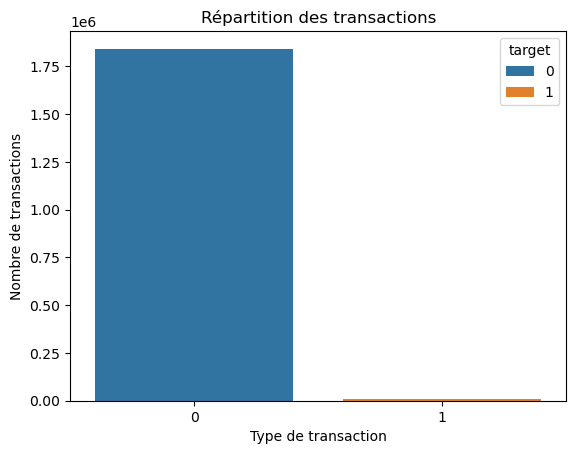

In [61]:
plt.title("Répartition des transactions")
plt.ylabel("Nombre de transactions")
plt.xlabel("Type de transaction")
sns.countplot(
    data=data_fraud,
    x="target",
    hue="target"
)
plt.show()


In [62]:
print("2019 : Nombre de transactions non frauduleuses/frauduleuses")
print(len(fraud_2019))
print(fraud_2019["target"].value_counts())

2019 : Nombre de transactions non frauduleuses/frauduleuses
924850
target
0    919630
1      5220
Name: count, dtype: int64


In [63]:
print("2020 : Nombre de transactions non frauduleuses/frauduleuses")
print(len(fraud_2020))
print(fraud_2020["target"].value_counts())

2020 : Nombre de transactions non frauduleuses/frauduleuses
927544
target
0    923113
1      4431
Name: count, dtype: int64


**Variables catégorielles**

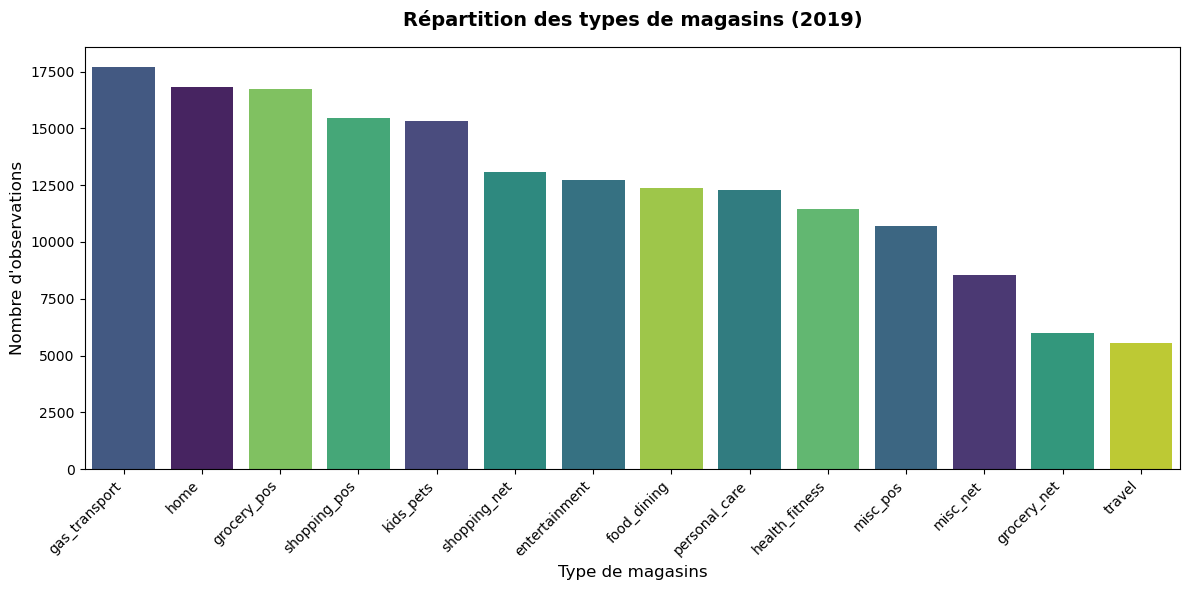

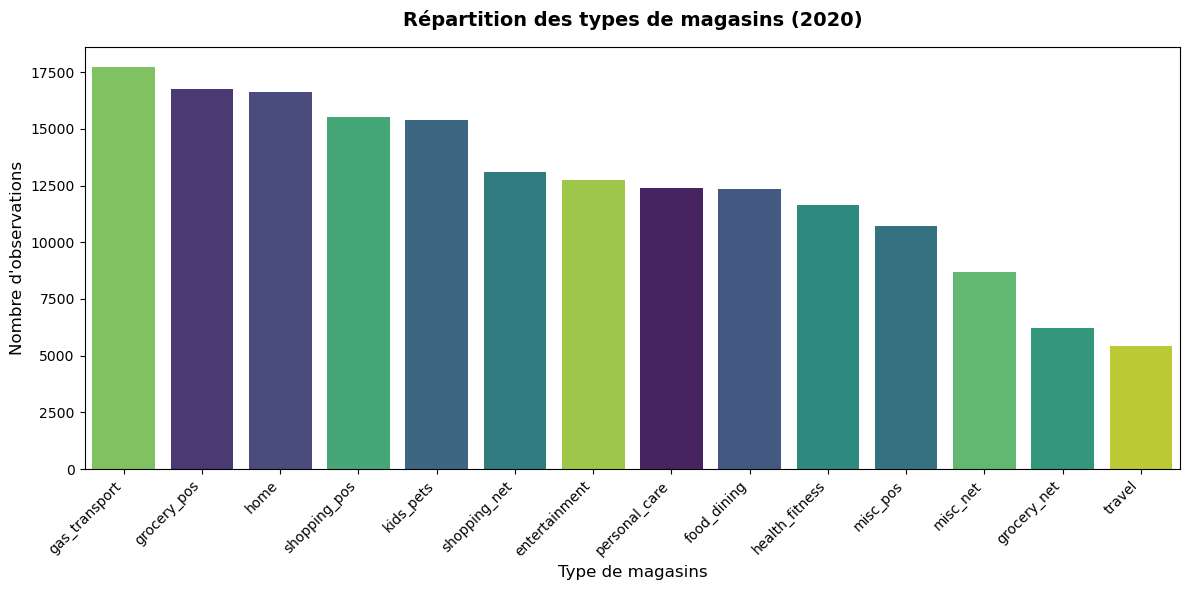

In [40]:
# Répartition des types de magasins où sont effectuées les transactions selon l'année

smart_countplot(
    df=fraud_2019,
    colonne="type_magasin",
    titre="Répartition des types de magasins (2019)",
    xlabel="Type de magasins",
    ylabel="Nombre d'observations"
)

smart_countplot(
    df=fraud_2020,
    colonne="type_magasin",
    titre="Répartition des types de magasins (2020)",
    xlabel="Type de magasins",
    ylabel="Nombre d'observations"
)

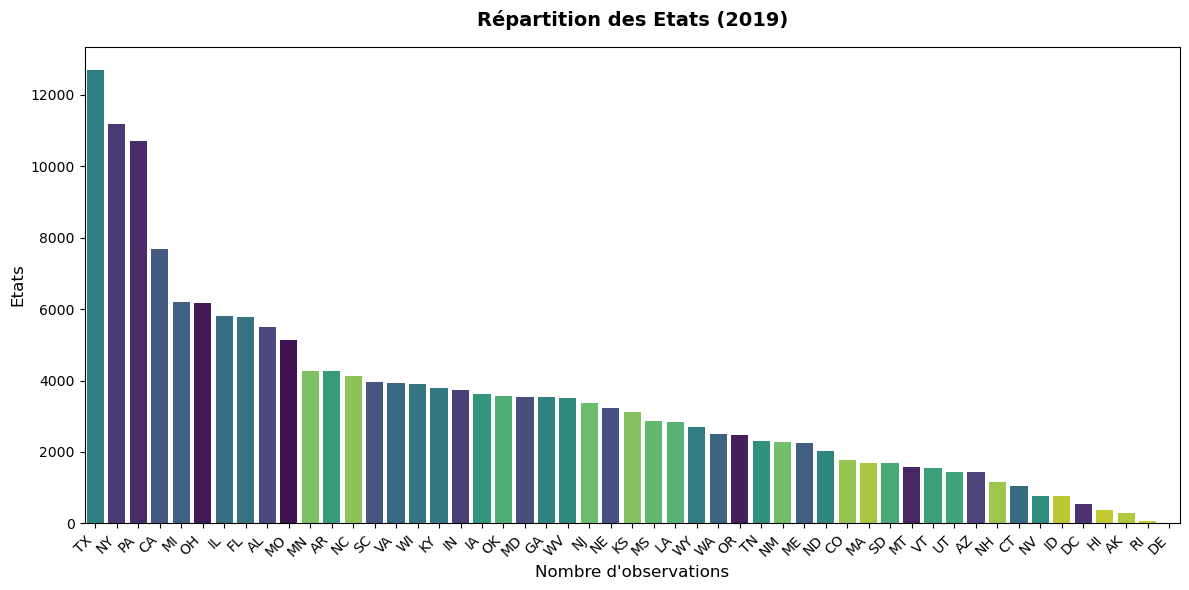

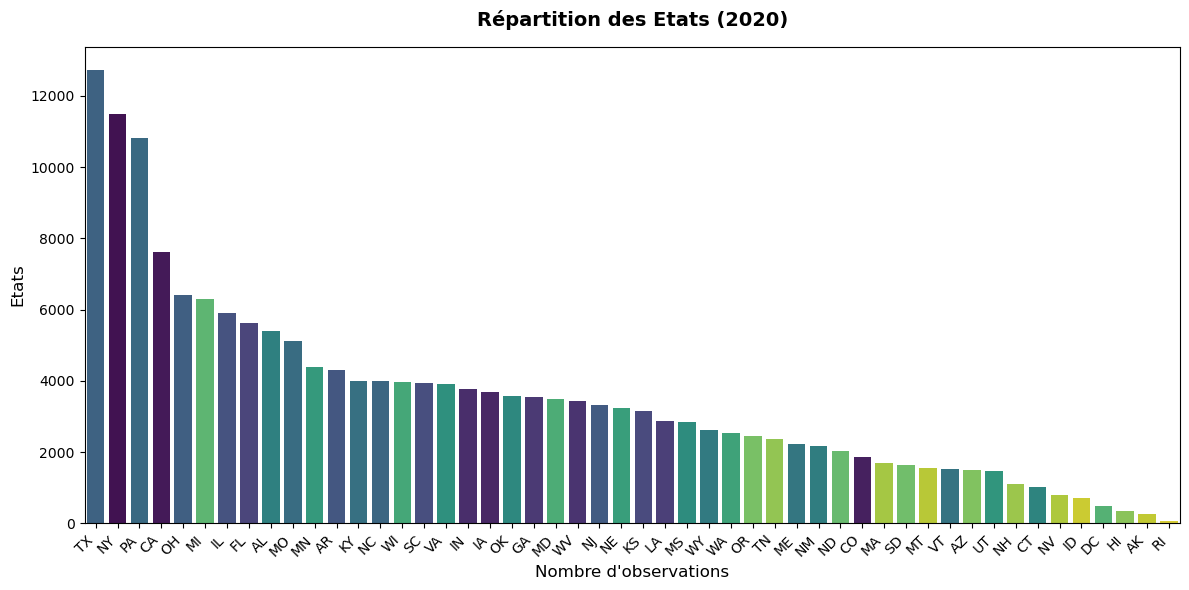

In [41]:
# Répartition des états ou sont effectuées les transactions selon l'année

smart_countplot(
    df=fraud_2019,
    colonne="etat_client",
    titre="Répartition des Etats (2019)",
    xlabel="Nombre d'observations",
    ylabel="Etats"
)

smart_countplot(
    df=fraud_2020,
    colonne="etat_client",
    titre="Répartition des Etats (2020)",
    xlabel="Nombre d'observations",
    ylabel="Etats"
)

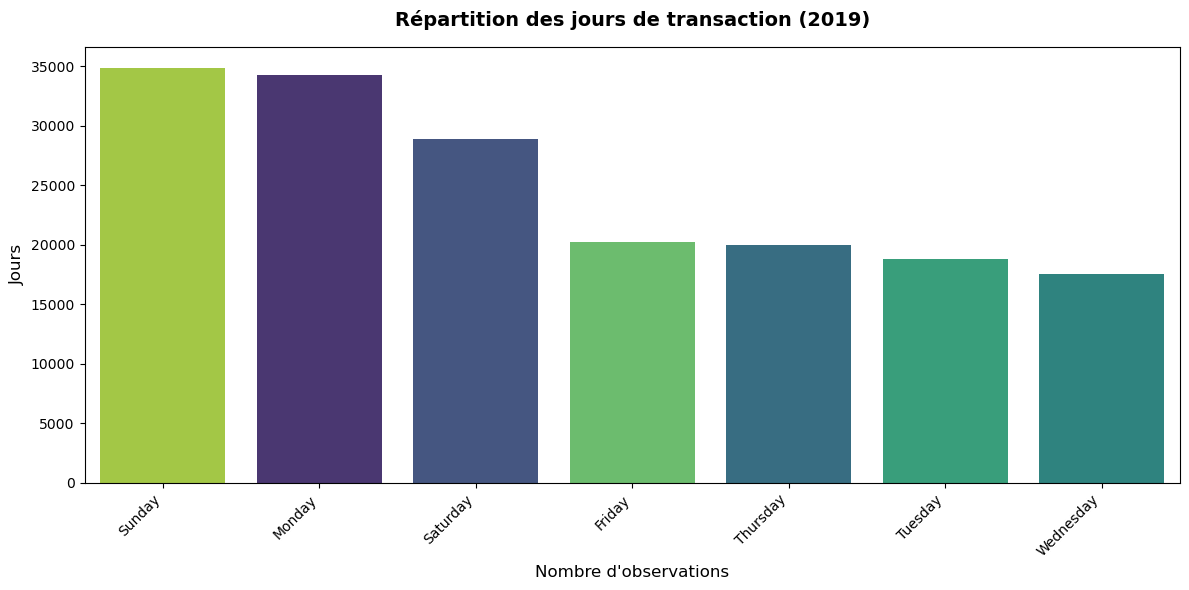

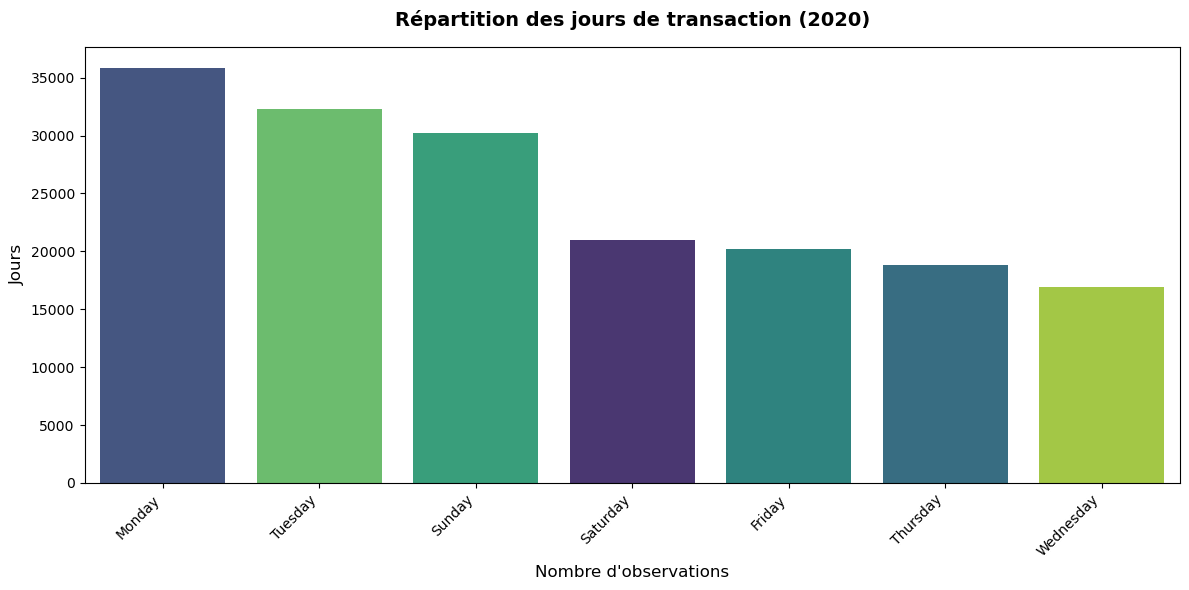

In [42]:
# Répartition des jours de transaction selon l'année
smart_countplot(
    df=fraud_2019,
    colonne="jour_transaction",
    titre="Répartition des jours de transaction (2019)",
    xlabel="Nombre d'observations",
    ylabel="Jours"
)

smart_countplot(
    df=fraud_2020,
    colonne="jour_transaction",
    titre="Répartition des jours de transaction (2020)",
    xlabel="Nombre d'observations",
    ylabel="Jours"
)

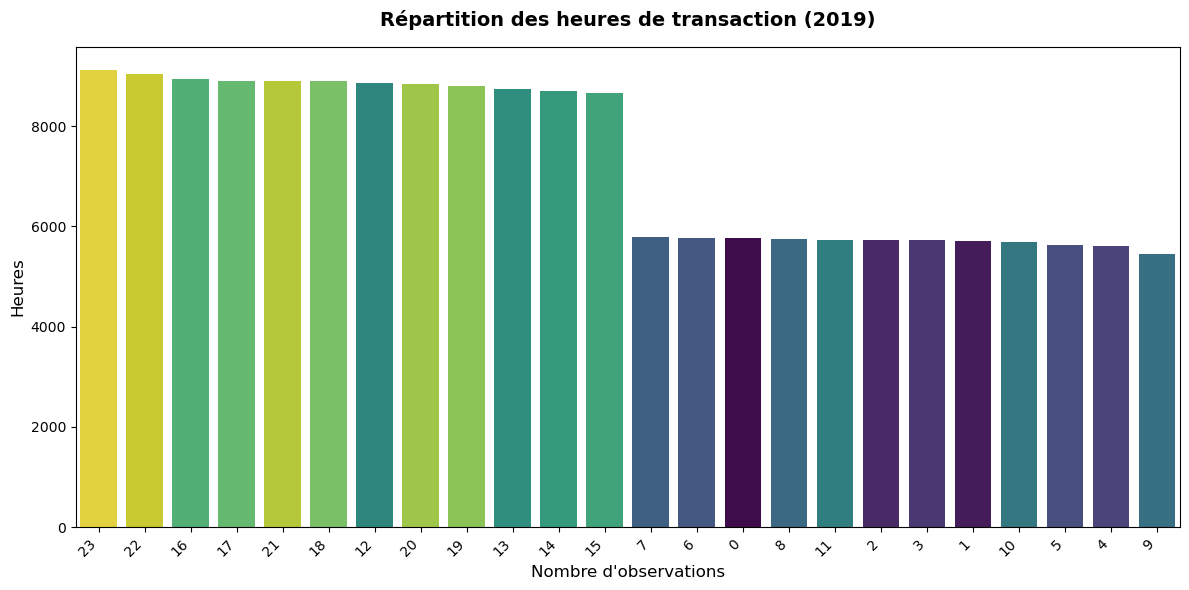

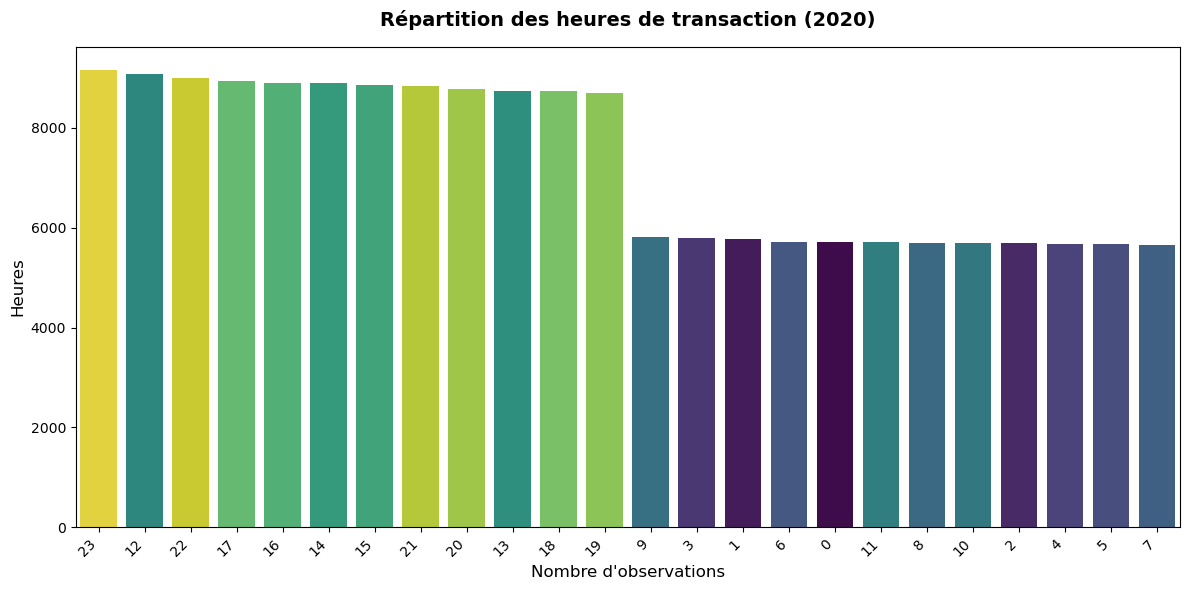

In [43]:
# Répartition des heures des transactions selon l'année
smart_countplot(
    df=fraud_2019,
    colonne="heure_transaction",
    titre="Répartition des heures de transaction (2019)",
    xlabel="Nombre d'observations",
    ylabel="Heures"
)

smart_countplot(
    df=fraud_2020,
    colonne="heure_transaction",
    titre="Répartition des heures de transaction (2020)",
    xlabel="Nombre d'observations",
    ylabel="Heures"
)

**Variables numériques**

In [44]:
variables_numeriques = ["montant_transaction","population_ville_client","age_client"]

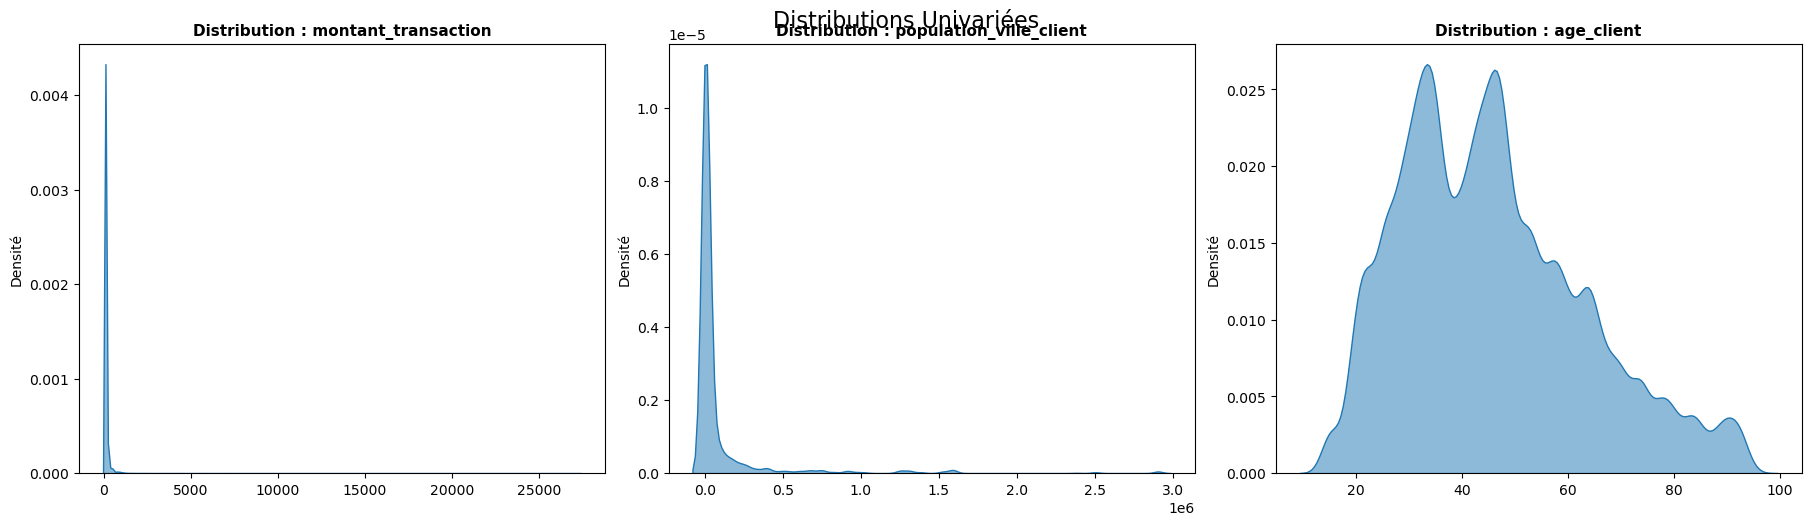

In [45]:
# Distribution des variables numériques en 2019
plot_kde_multivariables_grid(
    df=fraud_2019,
    features_cols=variables_numeriques
)

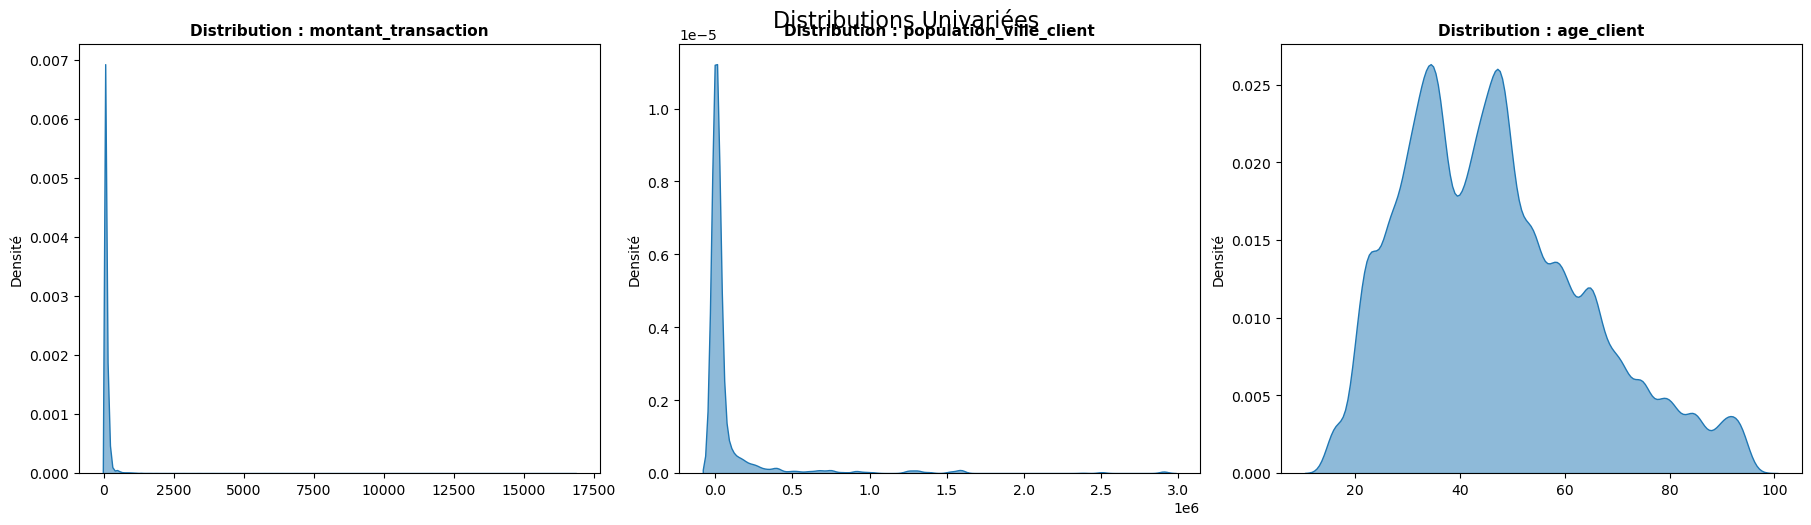

In [46]:
# Distribution des variables numériques en 2020
plot_kde_multivariables_grid(
    df=fraud_2020,
    features_cols=variables_numeriques
)

### Analyse bivariée

**Variables catégorielles**

In [47]:
variables_cat = ["type_magasin","etat_client","jour_transaction","heure_transaction"]

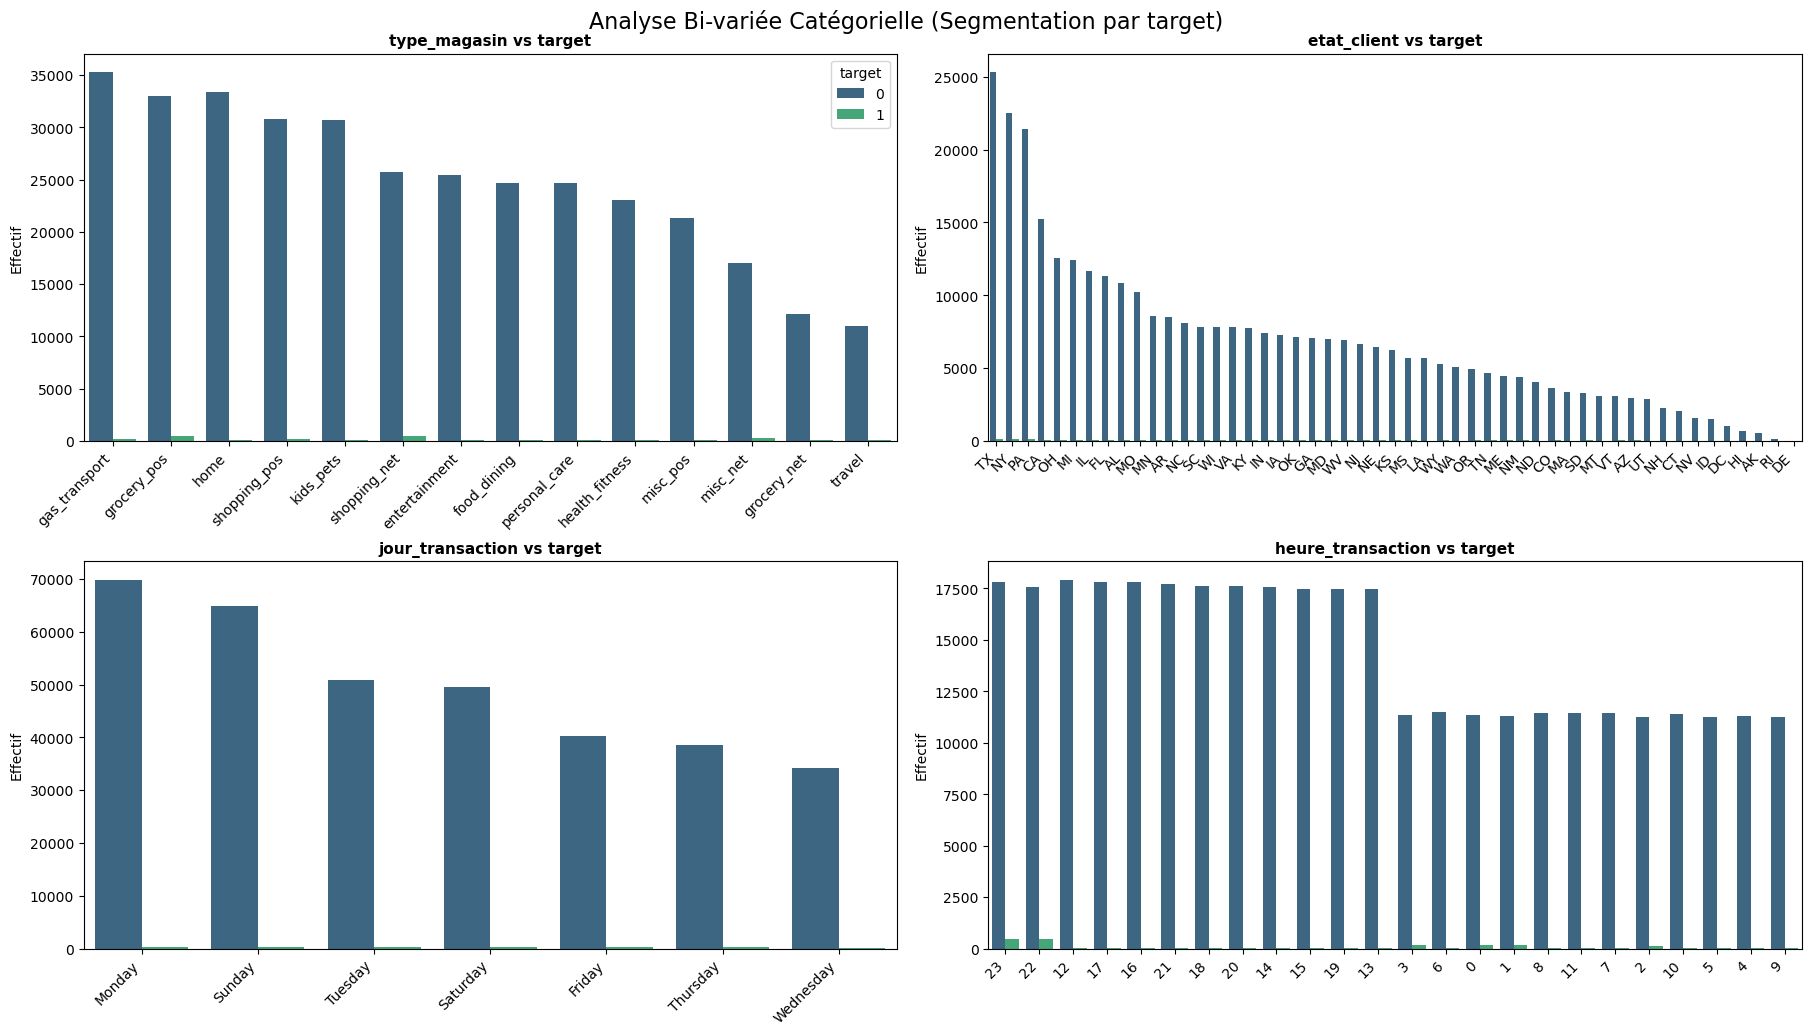

In [ ]:
# Comptage des des modalités de variables catégorielles en fonction de la variable cible (2019)
plot_countplots_bivarie_grid(
    fraud_2019,
    target_col="target",
    categorical_cols=variables_cat,
    n_cols=2
)

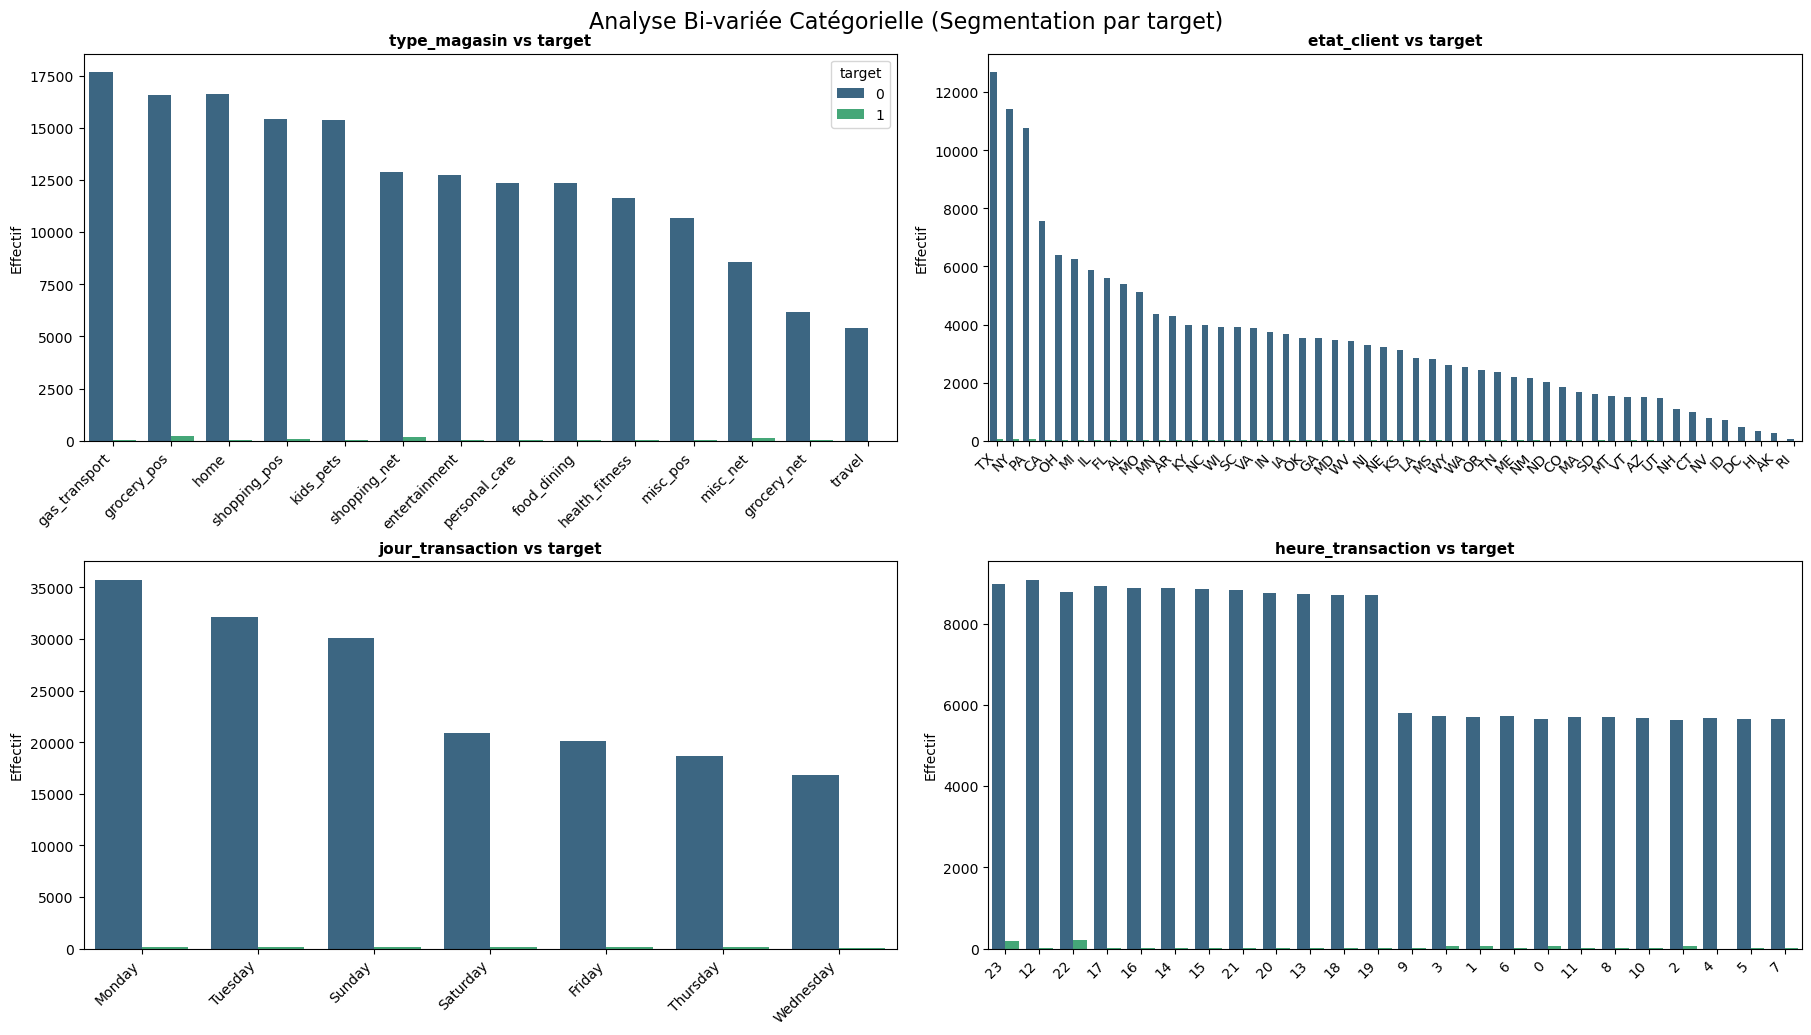

In [48]:
# Comptage des des modalités de variables catégorielles en fonction de la variable cible (2020)
plot_countplots_bivarie_grid(
    fraud_2020,
    target_col="target",
    categorical_cols=variables_cat,
    n_cols=2
)

**Variables numériques**

In [49]:
variables_numeriques = ["montant_transaction","population_ville_client","age_client"]

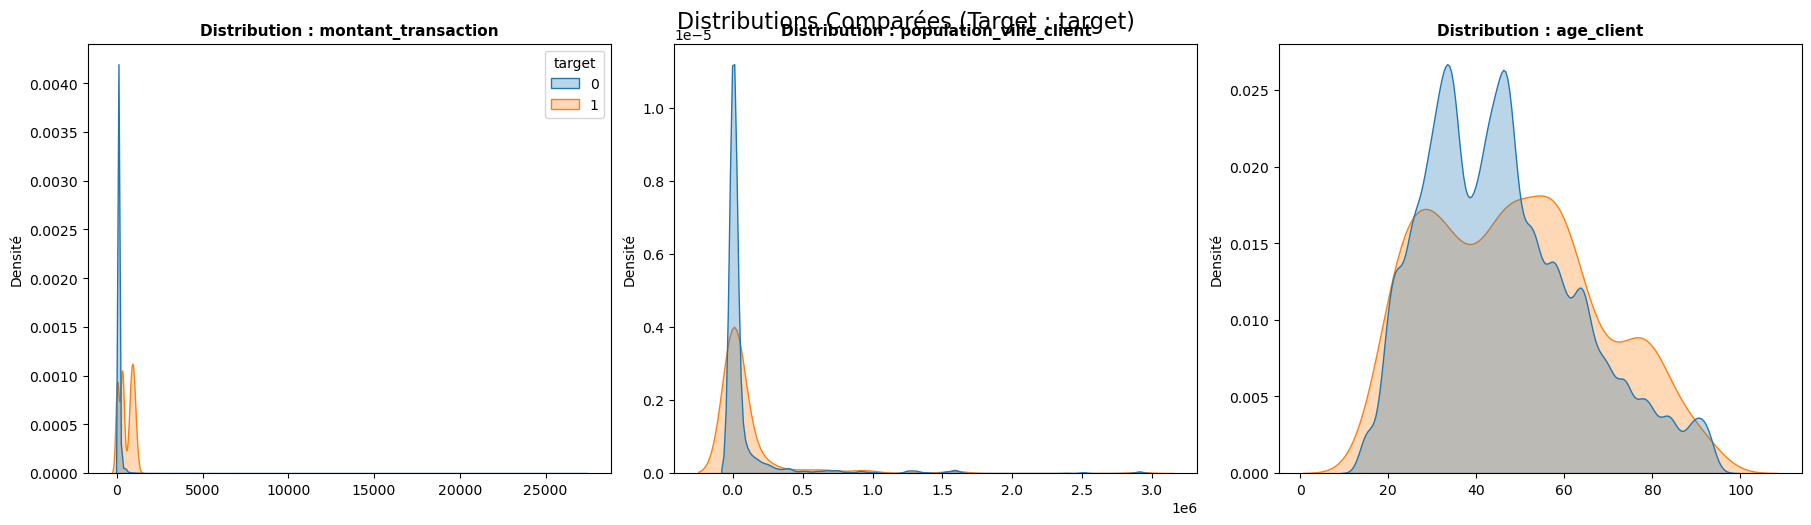

In [50]:
# Distribution des variables numériques en fonction de la target (2019)
plot_kde_multivariables_grid(
    df=fraud_2019,
    features_cols=variables_numeriques,
    target_col="target"
)

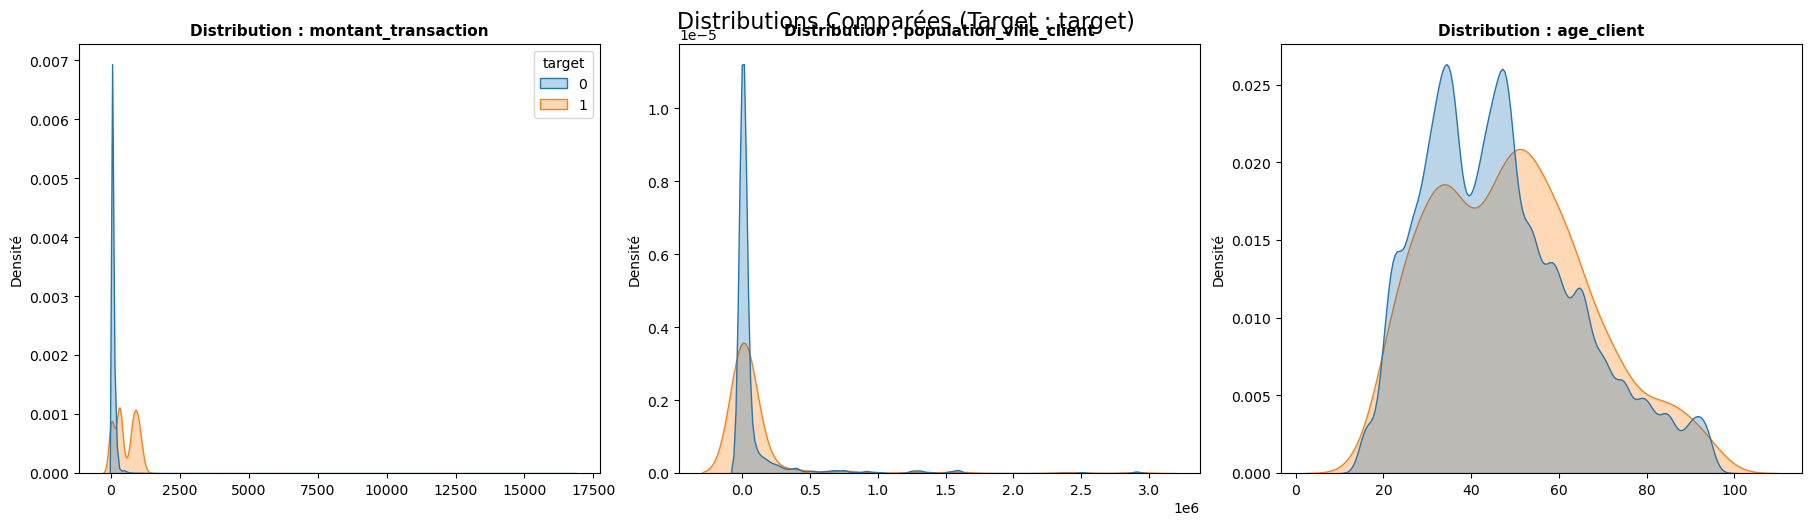

In [51]:
# Distribution des variables numériques en fonction de la target (2020)
plot_kde_multivariables_grid(
    df=fraud_2020,
    features_cols=variables_numeriques,
    target_col="target"
)

# Nettoyage post EDA

In [64]:
cleaning_post_eda()

Import des données : OK
Nettoyage de la variable 'etat_client' : OK
Export de la table modifiée : OK


# Note explicative du Notebook

Ce notebook a pour objectif de comprendre la structure des données nettoyées et d’orienter les choix de modélisation.  
Il s’appuie sur la table `data_fraud_processed.parquet` issue du premier notebook.

---

### 1. Analyse de la variable cible

La variable `target` est fortement déséquilibrée.

- Taux global de fraude proche de 0,05 %
- 2019 : environ 0,056 %
- 2020 : environ 0,047 %

La structure reste stable entre les deux années.  
Le déséquilibre impose une attention particulière lors de la phase de modélisation et du choix du seuil de décision.

---

### 2. Analyse des variables catégorielles

#### type_magasin

Certaines catégories apparaissent plus exposées à la fraude, notamment :

- grocery_pos  
- shopping_pos  
- misc_net  
- gas_transport  

La variable présente un pouvoir discriminant utile pour la modélisation.

#### etat_client

La variable comporte 50 modalités.  
Certaines sont très faiblement représentées.  

Après analyse, les modalités rares (DC, HI, AK, RI) sont regroupées dans une catégorie `other` afin de limiter la sparsité et stabiliser le modèle.  
Ce regroupement est formalisé dans un script dédié exécuté après l’EDA.

#### heure_transaction

La variable montre un pouvoir discriminant marqué, en particulier durant certaines heures nocturnes.

#### jour_transaction et mois_transaction

Ces variables présentent peu de pouvoir explicatif.  
Aucune différence structurante nette n’est observée entre fraude et transactions légitimes.

---

### 3. Analyse des variables continues

#### montant_transaction

La distribution diffère entre transactions frauduleuses et légitimes.  
Présence de valeurs extrêmes, mais compatibles avec un modèle de type gradient boosting.

#### age_client

La distribution varie selon la classe cible, ce qui suggère un signal exploitable.

#### population_ville_client

Distribution relativement similaire entre fraude et non-fraude.  
Pouvoir discriminant plus limité.

---

### 4. Stabilité temporelle

Les distributions des principales variables restent cohérentes entre 2019 et 2020.  
Il n’y a pas de rupture structurelle majeure, ce qui valide le choix :

- entraînement et validation sur 2019
- test sur 2020

---

### 5. Conséquences pour la modélisation

Variables retenues à l’issue de l’EDA :

- type_magasin  
- montant_transaction  
- etat_client  
- heure_transaction  
- distance_domicile_magasin  
- age_client  
- population_ville_client  

Variables écartées à l’issue de l’EDA :

- jour_transaction  
- mois_transaction  
- profession_client  
- ville_client  
- nom_magasin  

Les exclusions sont motivées par un faible pouvoir discriminant, une forte sparsité ou l’absence de structure stable.

---

### 6. Post-traitement

Un script complémentaire applique le regroupement des modalités rares de `etat_client`, puis exporte une nouvelle table :

`data_fraud_eda_processed.parquet`

Cette table constitue l’entrée du pipeline de modélisation.